<a href="https://colab.research.google.com/github/priyankak17/Deep-Learning-using-PyTorch/blob/main/Stable_diff_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Stable Diffusion text-to-image fine-tuning

In [1]:
%cd /content

!rm -rf diffusers
!git clone https://github.com/huggingface/diffusers.git

/content
Cloning into 'diffusers'...
remote: Enumerating objects: 135637, done.
remote: Total 135637 (delta 0), reused 0 (delta 0), pack-reused 135637 (from 1)
Receiving objects: 100% (135637/135637), 107.11 MiB | 30.97 MiB/s, done.
Resolving deltas: 100% (101968/101968), done.


In [2]:
%cd /content/diffusers

/content/diffusers


In [3]:
!pip install .

Processing /content/diffusers
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 29.8 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.41.0.dev0-py3-none-any.whl size=6029451 sha256=bf9fba446bcb058723aa6020aa83bf87f6112b9775cc2c3d8db011fb5b29d5b0
  Stored in directory: /tmp/pip-ephem-wheel-cache-oyggtyy1/wheels/ce/09/f1/683b43f8a222a091c8294e229524928cfaa64c9af69cd211b8
Successfully built diffusers
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.40.0
    Uninstalling diffusers-0.40.0:
      Successfully uninstalled diffusers-0.40.0


In [2]:
%cd /content/diffusers/examples/text_to_image

!pip install -r requirements.txt

/content/diffusers/examples/text_to_image


In [5]:
from accelerate.utils import write_basic_config

write_basic_config()

PosixPath('/root/.cache/huggingface/accelerate/default_config.yaml')

In [6]:
!pip uninstall torchao torchaudio -y

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [8]:
%cd /content/diffusers/examples/text_to_image

/content/diffusers/examples/text_to_image


In [9]:
import os

os.environ["MODEL_NAME"] = "stable-diffusion-v1-5/stable-diffusion-v1-5"
os.environ["DATASET_NAME"] = "lambdalabs/naruto-blip-captions"

print(os.environ["MODEL_NAME"])
print(os.environ["DATASET_NAME"])

stable-diffusion-v1-5/stable-diffusion-v1-5
lambdalabs/naruto-blip-captions


#Running smoke test of 10 epoch on A100 with 80vram memory

In [10]:
!accelerate launch \
    --mixed_precision="fp16" \
    train_text_to_image.py \
    --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
    --dataset_name="lambdalabs/naruto-blip-captions" \
    --image_column="image" \
    --caption_column="text" \
    --resolution=512 \
    --center_crop \
    --random_flip \
    --train_batch_size=1 \
    --gradient_accumulation_steps=4 \
    --gradient_checkpointing \
    --max_train_steps=10 \
    --learning_rate=1e-5 \
    --max_grad_norm=1 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --seed=42 \
    --output_dir="/content/sd-smoke-test"

09/27/2026 14:58:51 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
09/27/2026 14:58:52 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
09/27/2026 14:58:52 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stable-diffusion-v1-5/stable-diffusion-v1-5/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/scheduler%2Fscheduler_config.json?%2Fstable-diffusion-v1-5%2Fstable-diffusion-v1-5%2Fresolve%2Fmain%2Fscheduler%2Fscheduler_config.json=&etag=%2282d05b0e68

In [12]:
!ls -lah /content/sd-smoke-test

total 44K
drwxr-xr-x 10 root root 4.0K Sep 27 15:00 .
drwxr-xr-x  1 root root 4.0K Sep 27 15:00 ..
drwxr-xr-x  2 root root 4.0K Sep 27 15:00 feature_extractor
drwxr-xr-x  3 root root 4.0K Sep 27 14:59 logs
-rw-r--r--  1 root root  693 Sep 27 15:00 model_index.json
drwxr-xr-x  2 root root 4.0K Sep 27 15:00 safety_checker
drwxr-xr-x  2 root root 4.0K Sep 27 15:00 scheduler
drwxr-xr-x  2 root root 4.0K Sep 27 14:59 text_encoder
drwxr-xr-x  2 root root 4.0K Sep 27 14:59 tokenizer
drwxr-xr-x  2 root root 4.0K Sep 27 15:00 unet
drwxr-xr-x  2 root root 4.0K Sep 27 14:59 vae


#Inference

In [13]:
import torch
from diffusers import StableDiffusionPipeline

pipeline = StableDiffusionPipeline.from_pretrained(
    "/content/sd-smoke-test",
    torch_dtype=torch.float16,
    use_safetensors=True,
).to("cuda")

print("Pipeline loaded")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline loaded


  0%|          | 0/30 [00:00<?, ?it/s]

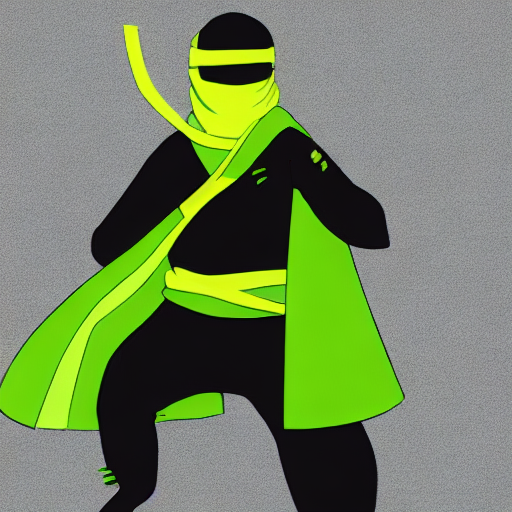

In [14]:
prompt = "a ninja character with bright green clothing"

image = pipeline(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

display(image)

In [15]:
image.save("/content/test_generation.png")

In [16]:
!pip install -U xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.6 MB/s eta 0:00:00


In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/tensorboard_logs

#Experiment A

In [3]:
!accelerate launch train_text_to_image.py \
    --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
    --dataset_name="lambdalabs/naruto-blip-captions" \
    --image_column="image" \
    --caption_column="text" \
    --resolution=512 \
    --train_batch_size=1 \
    --gradient_accumulation_steps=4 \
    --max_train_steps=100 \
    --learning_rate=1e-5 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --seed=42 \
    --output_dir="/content/experiment-A"

09/27/2026 15:04:53 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
09/27/2026 15:04:53 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
09/27/2026 15:04:53 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stable-diffusion-v1-5/stable-diffusion-v1-5/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/scheduler%2Fscheduler_config.json?%2Fstable-diffusion-v1-5%2Fstable-diffusion-v1-5%2Fresolve%2Fmain%2Fscheduler%2Fscheduler_config.json=&etag=%2282d05b0e688d

#Experiment B: FP16

In [4]:
!accelerate launch \
    --mixed_precision="fp16" \
    train_text_to_image.py \
    --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
    --dataset_name="lambdalabs/naruto-blip-captions" \
    --image_column="image" \
    --caption_column="text" \
    --resolution=512 \
    --train_batch_size=1 \
    --gradient_accumulation_steps=4 \
    --max_train_steps=100 \
    --learning_rate=1e-5 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --seed=42 \
    --output_dir="/content/experiment-B"

09/27/2026 15:07:29 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
09/27/2026 15:07:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
09/27/2026 15:07:29 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stable-diffusion-v1-5/stable-diffusion-v1-5/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/scheduler%2Fscheduler_config.json?%2Fstable-diffusion-v1-5%2Fstable-diffusion-v1-5%2Fresolve%2Fmain%2Fscheduler%2Fscheduler_config.json=&etag=%2282d05b0e68

#Experiment C: FP16 plus gradient checkpointing

In [5]:
!accelerate launch \
    --mixed_precision="fp16" \
    train_text_to_image.py \
    --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
    --dataset_name="lambdalabs/naruto-blip-captions" \
    --image_column="image" \
    --caption_column="text" \
    --resolution=512 \
    --train_batch_size=1 \
    --gradient_accumulation_steps=4 \
    --gradient_checkpointing \
    --max_train_steps=100 \
    --learning_rate=1e-5 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --seed=42 \
    --output_dir="/content/experiment-C"

09/27/2026 15:09:45 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
09/27/2026 15:09:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
09/27/2026 15:09:45 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stable-diffusion-v1-5/stable-diffusion-v1-5/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/scheduler%2Fscheduler_config.json?%2Fstable-diffusion-v1-5%2Fstable-diffusion-v1-5%2Fresolve%2Fmain%2Fscheduler%2Fscheduler_config.json=&etag=%2282d05b0e68

In [9]:
import os

experiment_dirs = {
    "A": "/content/experiment-A",
    "B": "/content/experiment-B",
    "C": "/content/experiment-C",
}

for exp, path in experiment_dirs.items():
    print(f"\nExperiment {exp}: {path}")

    if os.path.exists(path):
        print("✓ exists")
        print(os.listdir(path))
    else:
        print("✗ NOT FOUND")


Experiment A: /content/experiment-A
✓ exists
['tokenizer', 'safety_checker', 'vae', 'model_index.json', 'logs', 'text_encoder', 'unet', 'checkpoint-50', 'scheduler', 'feature_extractor']

Experiment B: /content/experiment-B
✓ exists
['tokenizer', 'safety_checker', 'vae', 'model_index.json', 'logs', 'text_encoder', 'unet', 'scheduler', 'feature_extractor']

Experiment C: /content/experiment-C
✓ exists
['tokenizer', 'safety_checker', 'vae', 'model_index.json', 'logs', 'text_encoder', 'unet', 'scheduler', 'feature_extractor']


In [10]:
experiments = {
    "A": {
        "local_dir": "/content/experiment-A",
        "repo_id": "pynk17/sd-naruto-fp32-baseline",
    },
    "B": {
        "local_dir": "/content/experiment-B",
        "repo_id": "pynk17/sd-naruto-fp16",
    },
    "C": {
        "local_dir": "/content/experiment-C",
        "repo_id": "pynk17/sd-naruto-fp16-grad-checkpointing",
    },
}

In [11]:
from huggingface_hub import HfApi
import os

api = HfApi()

for exp_name, config in experiments.items():
    local_dir = config["local_dir"]
    repo_id = config["repo_id"]

    print(f"\n{'='*60}")
    print(f"Uploading Experiment {exp_name}")
    print(f"Local: {local_dir}")
    print(f"Hub:   {repo_id}")
    print(f"{'='*60}")

    if not os.path.exists(local_dir):
        print(f"SKIPPED: {local_dir} does not exist")
        continue

    api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        exist_ok=True,
    )

    api.upload_folder(
        folder_path=local_dir,
        repo_id=repo_id,
        repo_type="model",
    )

    print(f"✓ Experiment {exp_name} uploaded successfully")


Uploading Experiment A
Local: /content/experiment-A
Hub:   pynk17/sd-naruto-fp32-baseline
✓ Experiment A uploaded successfully

Uploading Experiment B
Local: /content/experiment-B
Hub:   pynk17/sd-naruto-fp16
✓ Experiment B uploaded successfully

Uploading Experiment C
Local: /content/experiment-C
Hub:   pynk17/sd-naruto-fp16-grad-checkpointing
✓ Experiment C uploaded successfully



Testing: pynk17/sd-naruto-fp32-baseline


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

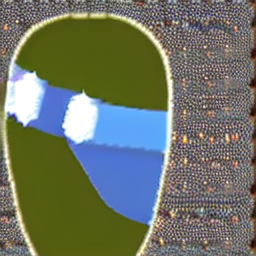

✓ pynk17/sd-naruto-fp32-baseline works

Testing: pynk17/sd-naruto-fp16


model_index.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


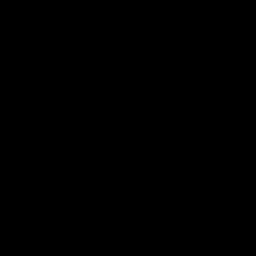

✓ pynk17/sd-naruto-fp16 works

Testing: pynk17/sd-naruto-fp16-grad-checkpointing


model_index.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


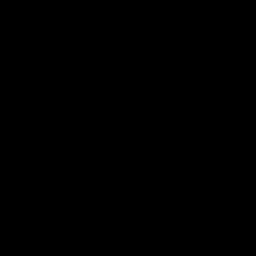

✓ pynk17/sd-naruto-fp16-grad-checkpointing works


In [12]:
import gc
import torch
from diffusers import StableDiffusionPipeline

repo_ids = [
    "pynk17/sd-naruto-fp32-baseline",
    "pynk17/sd-naruto-fp16",
    "pynk17/sd-naruto-fp16-grad-checkpointing",
]

for repo_id in repo_ids:
    print(f"\nTesting: {repo_id}")

    pipe = StableDiffusionPipeline.from_pretrained(
        repo_id,
        torch_dtype=torch.float16,
    ).to("cuda")

    image = pipe(
        "a ninja character wearing blue armor",
        num_inference_steps=20,
        height=256,
        width=256,
    ).images[0]

    display(image)

    del pipe
    torch.cuda.empty_cache()
    gc.collect()

    print(f"✓ {repo_id} works")

#Inference

In [13]:
import torch
import gc

from diffusers import StableDiffusionPipeline
from IPython.display import display

In [14]:
models = {
    "Experiment A - FP32": "pynk17/sd-naruto-fp32-baseline",
    "Experiment B - FP16": "pynk17/sd-naruto-fp16",
    "Experiment C - FP16 + Gradient Checkpointing":
        "pynk17/sd-naruto-fp16-grad-checkpointing",
}

In [15]:
PROMPT = "a ninja character with blue armor and spiky hair"
NEGATIVE_PROMPT = "blurry, low quality, distorted"

SEED = 42
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5

HEIGHT = 256
WIDTH = 256

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

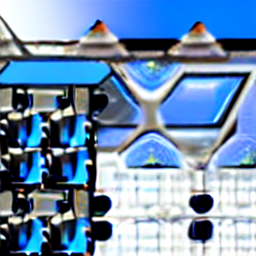

In [16]:
repo_id = models["Experiment A - FP32"]

pipe = StableDiffusionPipeline.from_pretrained(
    repo_id,
    torch_dtype=torch.float16,
).to("cuda")

generator = torch.Generator(
    device="cuda"
).manual_seed(SEED)

image_A = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    height=HEIGHT,
    width=WIDTH,
    generator=generator,
).images[0]

display(image_A)

image_A.save("/content/experiment_A.png")

In [17]:
del pipe

torch.cuda.empty_cache()
gc.collect()

print(
    "GPU allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

GPU allocated: 0.01 GB


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

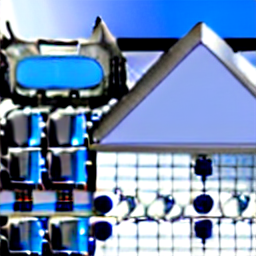

In [18]:
repo_id = models["Experiment B - FP16"]

pipe = StableDiffusionPipeline.from_pretrained(
    repo_id,
    torch_dtype=torch.float16,
).to("cuda")

generator = torch.Generator(
    device="cuda"
).manual_seed(SEED)

image_B = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    height=HEIGHT,
    width=WIDTH,
    generator=generator,
).images[0]

display(image_B)

image_B.save("/content/experiment_B.png")

In [21]:
del pipe

torch.cuda.empty_cache()
gc.collect()

3244

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

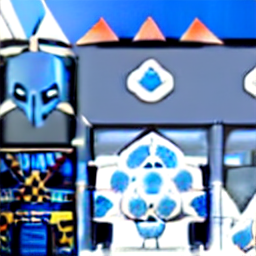

In [20]:
repo_id = models["Experiment C - FP16 + Gradient Checkpointing"]

pipe = StableDiffusionPipeline.from_pretrained(
    repo_id,
    torch_dtype=torch.float16,
).to("cuda")

generator = torch.Generator(
    device="cuda"
).manual_seed(SEED)

image_C = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    height=HEIGHT,
    width=WIDTH,
    generator=generator,
).images[0]

display(image_C)

image_C.save("/content/experiment_C.png")

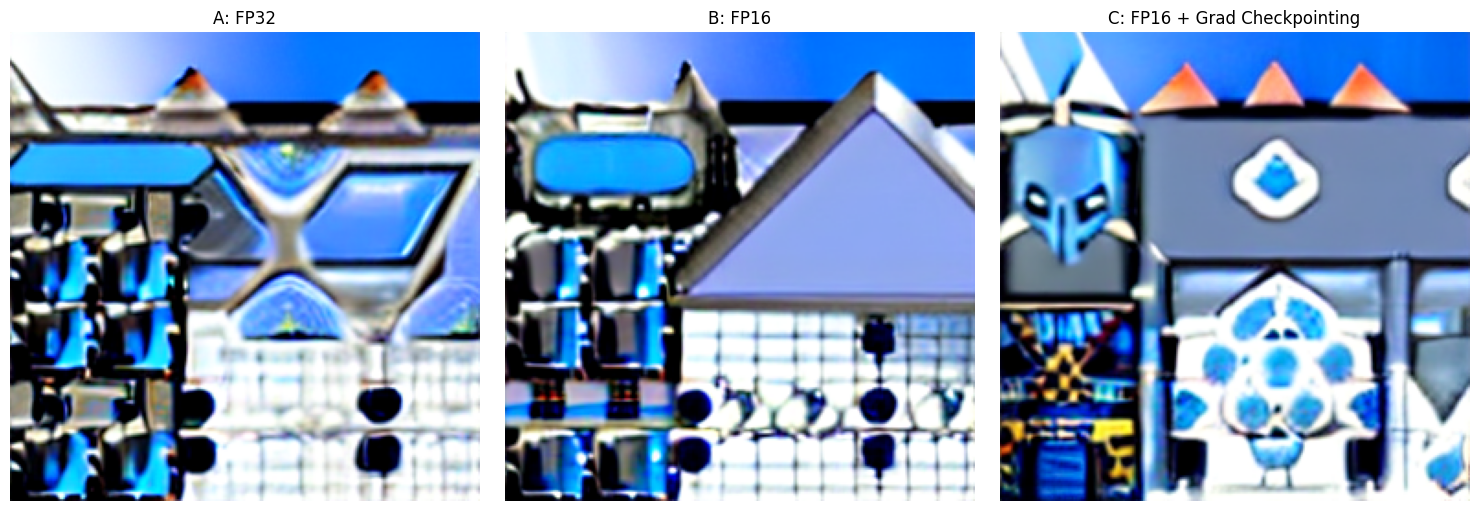

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [
    image_A,
    image_B,
    image_C,
]

titles = [
    "A: FP32",
    "B: FP16",
    "C: FP16 + Grad Checkpointing",
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
TEST_PROMPTS = [
    "a ninja character with blue armor and spiky hair",
    "a female ninja character standing in a forest",
    "a ninja character using a fire attack",
    "a ninja character wearing black clothes at night",
    "a ninja character portrait, detailed face",
]

In [24]:
import os
import gc
import time
import torch
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline


# ============================================================
# 1. MODELS
# ============================================================

MODELS = {
    "A_FP32": "pynk17/sd-naruto-fp32-baseline",
    "B_FP16": "pynk17/sd-naruto-fp16",
    "C_FP16_GC": "pynk17/sd-naruto-fp16-grad-checkpointing",
}


# ============================================================
# 2. TEST PROMPTS
# ============================================================

TEST_PROMPTS = [
    "a ninja character with blue armor and spiky hair",
    "a female ninja character standing in a forest",
    "a ninja character using a fire attack",
    "a ninja character wearing black clothes at night",
    "a detailed portrait of a ninja character",
]


# ============================================================
# 3. CONTROLLED INFERENCE CONFIGURATION
# ============================================================

NEGATIVE_PROMPT = "blurry, low quality, distorted, deformed"

SEED = 42
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5

HEIGHT = 256
WIDTH = 256

OUTPUT_DIR = "/content/inference_comparison"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 4. STORE RESULTS
# ============================================================

results = {}

timing_results = {}


# ============================================================
# 5. RUN INFERENCE
# ============================================================

for model_name, repo_id in MODELS.items():

    print("\n" + "=" * 70)
    print(f"Testing: {model_name}")
    print(f"Repository: {repo_id}")
    print("=" * 70)

    model_output_dir = os.path.join(
        OUTPUT_DIR,
        model_name
    )

    os.makedirs(
        model_output_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Load one model onto GPU
    # --------------------------------------------------------

    print("\nLoading model...")

    pipe = StableDiffusionPipeline.from_pretrained(
        repo_id,
        torch_dtype=torch.float16,
    ).to("cuda")

    pipe.set_progress_bar_config(
        disable=False
    )

    model_images = []
    model_times = []

    # --------------------------------------------------------
    # Run every prompt
    # --------------------------------------------------------

    for prompt_index, prompt in enumerate(TEST_PROMPTS):

        print("\n" + "-" * 60)
        print(
            f"{model_name} | "
            f"Prompt {prompt_index + 1}/{len(TEST_PROMPTS)}"
        )
        print(prompt)

        # Reset seed for EVERY generation.
        #
        # This is important because each model should receive
        # the same initial random noise for the same prompt.

        generator = torch.Generator(
            device="cuda"
        ).manual_seed(SEED)

        torch.cuda.synchronize()

        start_time = time.perf_counter()

        with torch.inference_mode():

            image = pipe(
                prompt=prompt,
                negative_prompt=NEGATIVE_PROMPT,
                num_inference_steps=NUM_INFERENCE_STEPS,
                guidance_scale=GUIDANCE_SCALE,
                height=HEIGHT,
                width=WIDTH,
                generator=generator,
            ).images[0]

        torch.cuda.synchronize()

        inference_time = (
            time.perf_counter() - start_time
        )

        model_times.append(inference_time)
        model_images.append(image.copy())

        # Save individual image

        image_path = os.path.join(
            model_output_dir,
            f"prompt_{prompt_index + 1}.png"
        )

        image.save(image_path)

        print(
            f"Saved: {image_path}"
        )

        print(
            f"Inference time: "
            f"{inference_time:.2f} seconds"
        )

    # --------------------------------------------------------
    # Store this model's results
    # --------------------------------------------------------

    results[model_name] = model_images
    timing_results[model_name] = model_times

    # --------------------------------------------------------
    # Remove model before loading next model
    # --------------------------------------------------------

    print(
        f"\nFinished {model_name}. "
        "Clearing GPU memory..."
    )

    del pipe

    gc.collect()
    torch.cuda.empty_cache()

    print(
        "GPU allocated after cleanup:",
        round(
            torch.cuda.memory_allocated()
            / 1024**3,
            2
        ),
        "GB"
    )


print("\n✓ Inference complete for all models.")


Testing: A_FP32
Repository: pynk17/sd-naruto-fp32-baseline

Loading model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]


------------------------------------------------------------
A_FP32 | Prompt 1/5
a ninja character with blue armor and spiky hair


...

Saved: /content/inference_comparison/C_FP16_GC/prompt_3.png
Inference time: 1.37 seconds

------------------------------------------------------------
C_FP16_GC | Prompt 4/5
a ninja character wearing black clothes at night


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: /content/inference_comparison/C_FP16_GC/prompt_4.png
Inference time: 1.39 seconds

------------------------------------------------------------
C_FP16_GC | Prompt 5/5
a detailed portrait of a ninja character


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: /content/inference_comparison/C_FP16_GC/prompt_5.png
Inference time: 1.39 seconds

Finished C_FP16_GC. Clearing GPU memory...
GPU allocated after cleanup: 0.01 GB

✓ Inference complete for all models.


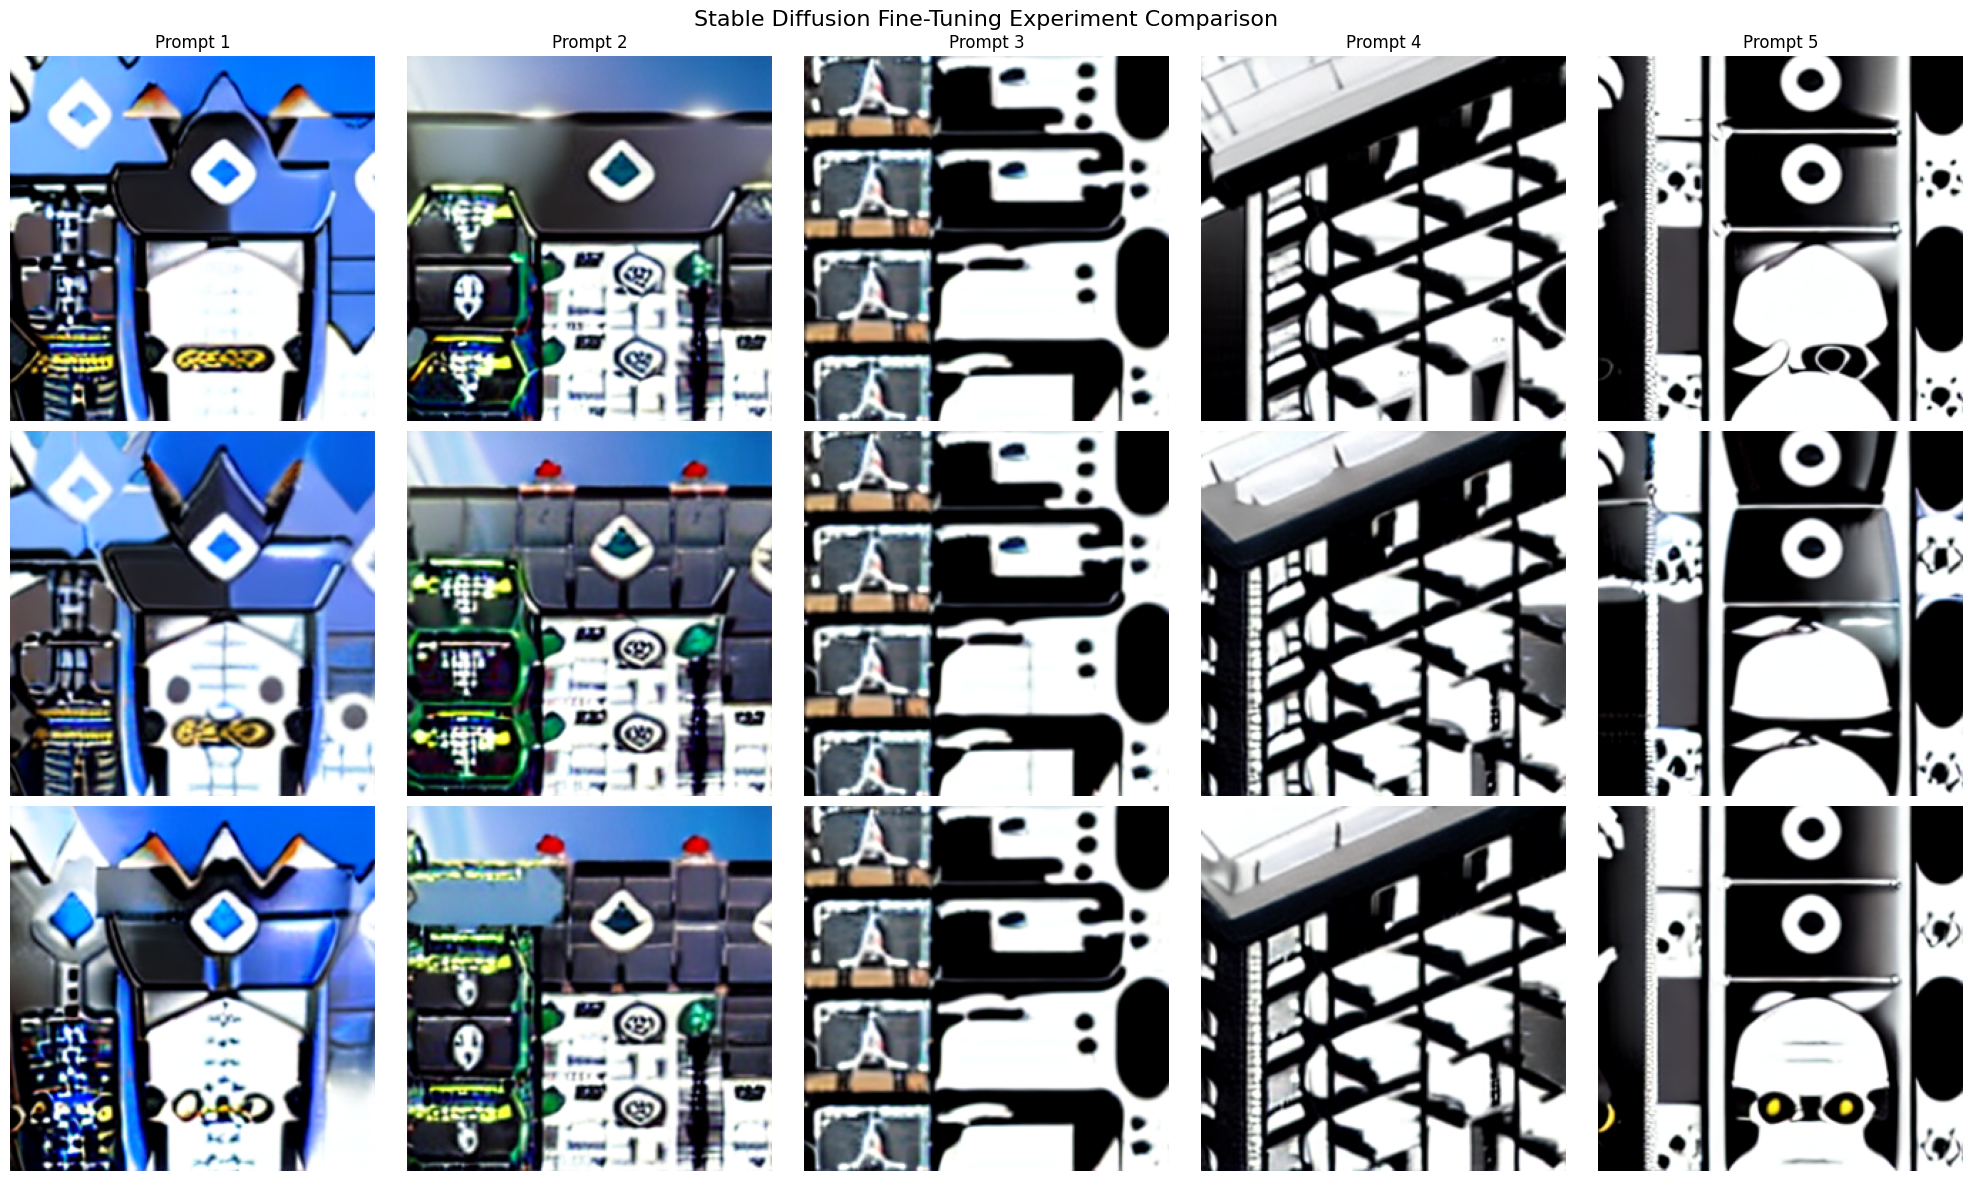

Comparison saved to: /content/inference_comparison/all_models_comparison.png


In [25]:
# ============================================================
# 6. CREATE COMPARISON GRID
# ============================================================

model_names = list(MODELS.keys())

num_models = len(model_names)
num_prompts = len(TEST_PROMPTS)

fig, axes = plt.subplots(
    num_models,
    num_prompts,
    figsize=(4 * num_prompts, 4 * num_models)
)

for row, model_name in enumerate(model_names):

    for col, prompt in enumerate(TEST_PROMPTS):

        ax = axes[row, col]

        ax.imshow(
            results[model_name][col]
        )

        ax.axis("off")

        if row == 0:
            ax.set_title(
                f"Prompt {col + 1}",
                fontsize=12
            )

        if col == 0:
            ax.set_ylabel(
                model_name,
                fontsize=12
            )


plt.suptitle(
    "Stable Diffusion Fine-Tuning Experiment Comparison",
    fontsize=16
)

plt.tight_layout()

comparison_path = os.path.join(
    OUTPUT_DIR,
    "all_models_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Comparison saved to: {comparison_path}"
)

In [26]:
for i, prompt in enumerate(TEST_PROMPTS, start=1):
    print(f"Prompt {i}: {prompt}")

Prompt 1: a ninja character with blue armor and spiky hair
Prompt 2: a female ninja character standing in a forest
Prompt 3: a ninja character using a fire attack
Prompt 4: a ninja character wearing black clothes at night
Prompt 5: a detailed portrait of a ninja character


In [27]:
import numpy as np

print("\nAverage inference time")
print("=" * 50)

for model_name, times in timing_results.items():

    mean_time = np.mean(times)
    std_time = np.std(times)

    print(
        f"{model_name:15s} "
        f"{mean_time:.2f} ± {std_time:.2f} sec/image"
    )


Average inference time
A_FP32          1.37 ± 0.02 sec/image
B_FP16          1.39 ± 0.02 sec/image
C_FP16_GC       1.40 ± 0.02 sec/image


#after training begins or completes re-run to log results

In [8]:
%tensorboard --logdir /content/tensorboard_logs

UsageError: Line magic function `%tensorboard` not found.


In [ ]:
--report_to="tensorboard"
--logging_dir="/content/tensorboard_logs/exp-A-fp32"

In [ ]:
--report_to="tensorboard"
--logging_dir="/content/tensorboard_logs/exp-B-fp16"

In [ ]:
--report_to="tensorboard"
--logging_dir="/content/tensorboard_logs/exp-C-fp16-gc"

In [ ]:
from huggingface_hub import notebook_login

notebook_login()